# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from environments.optimal_stopping import OptimalStoppingEnv
from function_approximation.linear_fa import LinearFA
from function_approximation.polynomial_fa import PolynomialFA
from algorithms.rpi import RPI
from algorithms.crpi import CRPI
from utils import solve_tabular_pi

In [2]:
import cvxpy as cp
print(f"Installed solvers: {cp.installed_solvers()}")


Installed solvers: ['CLARABEL', 'ECOS', 'ECOS_BB', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


In [ ]:
# import numpy as np
# from abc import ABC, abstractmethod

# class BaseFA(ABC):
#     """
#     Abstract Base Class for Function Approximation in RPI/CRPI.
#     """
    
#     @abstractmethod
#     def evaluate_policy(self, P_mu: np.ndarray, r: np.ndarray, gamma: float, f_k: np.ndarray) -> np.ndarray:
#         """
#         Solves the constrained optimization problem to find the new value estimate f_{k+1}.
        
#         Args:
#             P_mu (np.ndarray): The SA x SA transition matrix for the current policy mu.
#             r (np.ndarray): The SA x 1 reward vector.
#             gamma (float): The discount factor.
#             f_k (np.ndarray): The SA x 1 vector of the previous value estimate.
            
#         Returns:
#             np.ndarray: The SA x 1 vector representing the new value estimate f_{k+1}.
#         """
#         pass

In [ ]:
# import numpy as np
# import cvxpy as cp

# class LinearFA(BaseFA):
#     def __init__(self, Phi: np.ndarray):
#         """
#         Linear Function Approximation.
        
#         Args:
#             Phi (np.ndarray): The feature matrix of shape (SA, d). SA = number of state-action pairs, d = number of features.
#         """
#         self.Phi = Phi
#         self.SA, self.d = Phi.shape
#         # theta is the weight vector we are trying to optimize
#         self.theta = cp.Variable(self.d) # The solver will tweak these 5 variables (weights) to find the optimal solution.

#     def evaluate_policy(self, P_mu: np.ndarray, r: np.ndarray, gamma: float, f_k: np.ndarray) -> np.ndarray:
#         """
#         Solves the LP to find the weights theta that maximize the l1 distance 
#         from f_k subject to the Bellman constraints.
#         """
#         # Define the function f = Phi * theta
#         f = self.Phi @ self.theta 
        
#         # Reshape inputs to ensure 1D arrays for CVXPY compatibility
#         r = r.flatten()
#         f_k = f_k.flatten()

#         # Add a tiny numerical slack to prevent floating-point infeasibility
#         epsilon = 1e-4

#         # Constraint 1: f >= f_k 
#         # (This ensures monotonic reliability under FA)
#         constraint_1 = f >= f_k - epsilon

#         # Constraint 2: T_mu(f) >= f  =>  (I - gamma * P_mu) @ f <= r
#         I = np.eye(self.SA)
#         bellman_matrix = I - gamma * P_mu
#         constraint_2 = bellman_matrix @ f <= r + epsilon

#         constraints = [constraint_1, constraint_2]

#         # Objective: Maximize the l1-norm of (f - f_k). 
#         # Since constraint_1 guarantees f >= f_k, all terms are positive.
#         # Thus, maximizing sum(f - f_k) is equivalent to maximizing sum(f).
#         objective = cp.Maximize(cp.sum(f))

#         # Define and solve the problem
#         prob = cp.Problem(objective, constraints)
        
#         try:
#             # ECOS and SCS are good open-source solvers included with cvxpy
#             prob.solve(solver=cp.ECOS)
            
#             # this should not be the case according to claim 3.1 
#             if prob.status not in ["optimal", "optimal_inaccurate"]:
#                 raise ValueError(f"Optimization failed. Status: {prob.status}")
                
#         except Exception as e:
#             print(f"Warning: LP Solver failed with error: {e}. Returning f_k as fallback.")
#             return f_k.reshape(-1, 1) # Fallback to prevent complete crash

#         # Compute the final f_{k+1} using the optimized theta
#         f_k_plus_1 = self.Phi @ self.theta.value
#         return f_k_plus_1.reshape(-1, 1)

In [3]:
# --- CELL 2 ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Environment Setup
env = OptimalStoppingEnv(N=60, cost=0.05)
gamma = 0.9
iters = 50
d_features = 4
n_seeds = 10  # We run 10 seeds here to generate the shaded regions

P, R = env.get_mdp_matrices()
SA = P.shape[0] * P.shape[1]
nu = np.ones((SA, 1)) / SA

# Get the true optimal baseline using Tabular PI
_, Q_opt = solve_tabular_pi(env, gamma)
optimal_return = (nu.T @ Q_opt).item()

# 2. Execute Training
rpi_all_true, crpi_all_true = [], []
rpi_seed0_true, rpi_seed0_est = None, None
crpi_seed0_true, crpi_seed0_est = None, None

Running 10 seeds for Cell 2. This may take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 comp

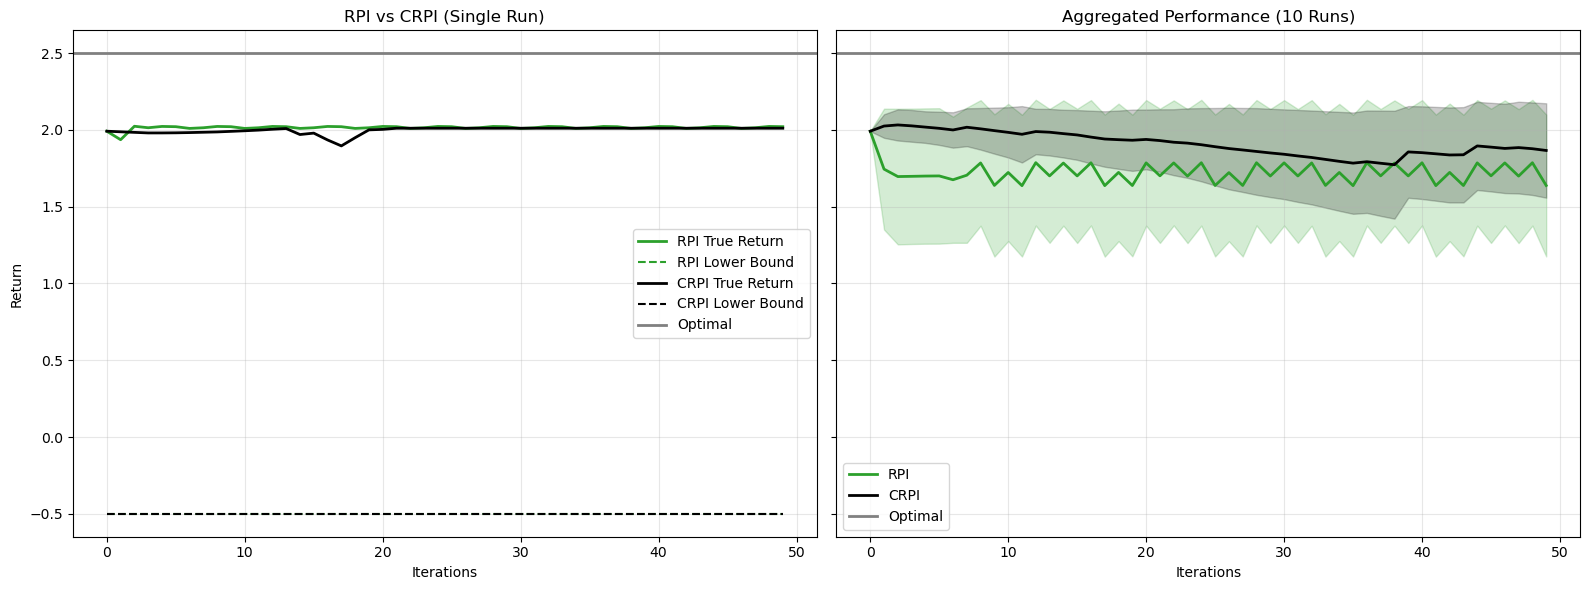

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,84.3 ± 19.4,1.64 ± 0.46
1,CRPI,93.5 ± 9.3,1.87 ± 0.31


In [ ]:
print(f"Running {n_seeds} seeds for Cell 2. This may take a moment...")

for seed in range(n_seeds):
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0 # Bias column to prevent infeasibility

    # Train RPI
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    _, _, r_hist = rpi_agent.train(track_metrics=True)
    rpi_all_true.append(r_hist['true_return'])

    # Train CRPI
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    _, _, c_hist = crpi_agent.train(track_metrics=True)
    crpi_all_true.append(c_hist['true_return'])

    # Save the very first seed's history for the single-run plot
    if seed == 0:
        rpi_seed0_true = r_hist['true_return']
        rpi_seed0_est = r_hist['est_return']
        crpi_seed0_true = c_hist['true_return']
        crpi_seed0_est = c_hist['est_return']

rpi_all_true = np.array(rpi_all_true)
crpi_all_true = np.array(crpi_all_true)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subplot 1: Single Run (RPI vs CRPI overlay)
ax1.plot(rpi_seed0_true, color='#2ca02c', label='RPI True Return', linewidth=2)
ax1.plot(rpi_seed0_est, color='#2ca02c', linestyle='--', label='RPI Lower Bound')
ax1.plot(crpi_seed0_true, color='#000000', label='CRPI True Return', linewidth=2)
ax1.plot(crpi_seed0_est, color='#000000', linestyle='--', label='CRPI Lower Bound')
ax1.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax1.set_title("RPI vs CRPI (Single Run)")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Aggregated Performance (Mean ± 1 Std Dev)
rpi_mean = np.mean(rpi_all_true, axis=0)
rpi_std = np.std(rpi_all_true, axis=0)
crpi_mean = np.mean(crpi_all_true, axis=0)
crpi_std = np.std(crpi_all_true, axis=0)

ax2.plot(rpi_mean, color='#2ca02c', label='RPI', linewidth=2)
ax2.fill_between(range(iters), rpi_mean - rpi_std, rpi_mean + rpi_std, color='#2ca02c', alpha=0.2)
ax2.plot(crpi_mean, color='#000000', label='CRPI', linewidth=2)
ax2.fill_between(range(iters), crpi_mean - crpi_std, crpi_mean + crpi_std, color='#000000', alpha=0.2)
ax2.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax2.set_title(f"Aggregated Performance ({n_seeds} Runs)")
ax2.set_xlabel("Iterations")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Generate Metrics Table using trapezoid
rpi_aucs = [np.trapezoid(run) for run in rpi_all_true]
crpi_aucs = [np.trapezoid(run) for run in crpi_all_true]

data = {
    "Algorithm": ["RPI", "CRPI"],
    "AUC (mean ± std)": [f"{np.mean(rpi_aucs):.1f} ± {np.std(rpi_aucs):.1f}",
                         f"{np.mean(crpi_aucs):.1f} ± {np.std(crpi_aucs):.1f}"],
    "Terminal Perf. (mean ± std)": [f"{rpi_mean[-1]:.2f} ± {rpi_std[-1]:.2f}",
                                    f"{crpi_mean[-1]:.2f} ± {crpi_std[-1]:.2f}"]
}
df = pd.DataFrame(data)
display(df)

Running 6 detailed runs. This will take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 complet

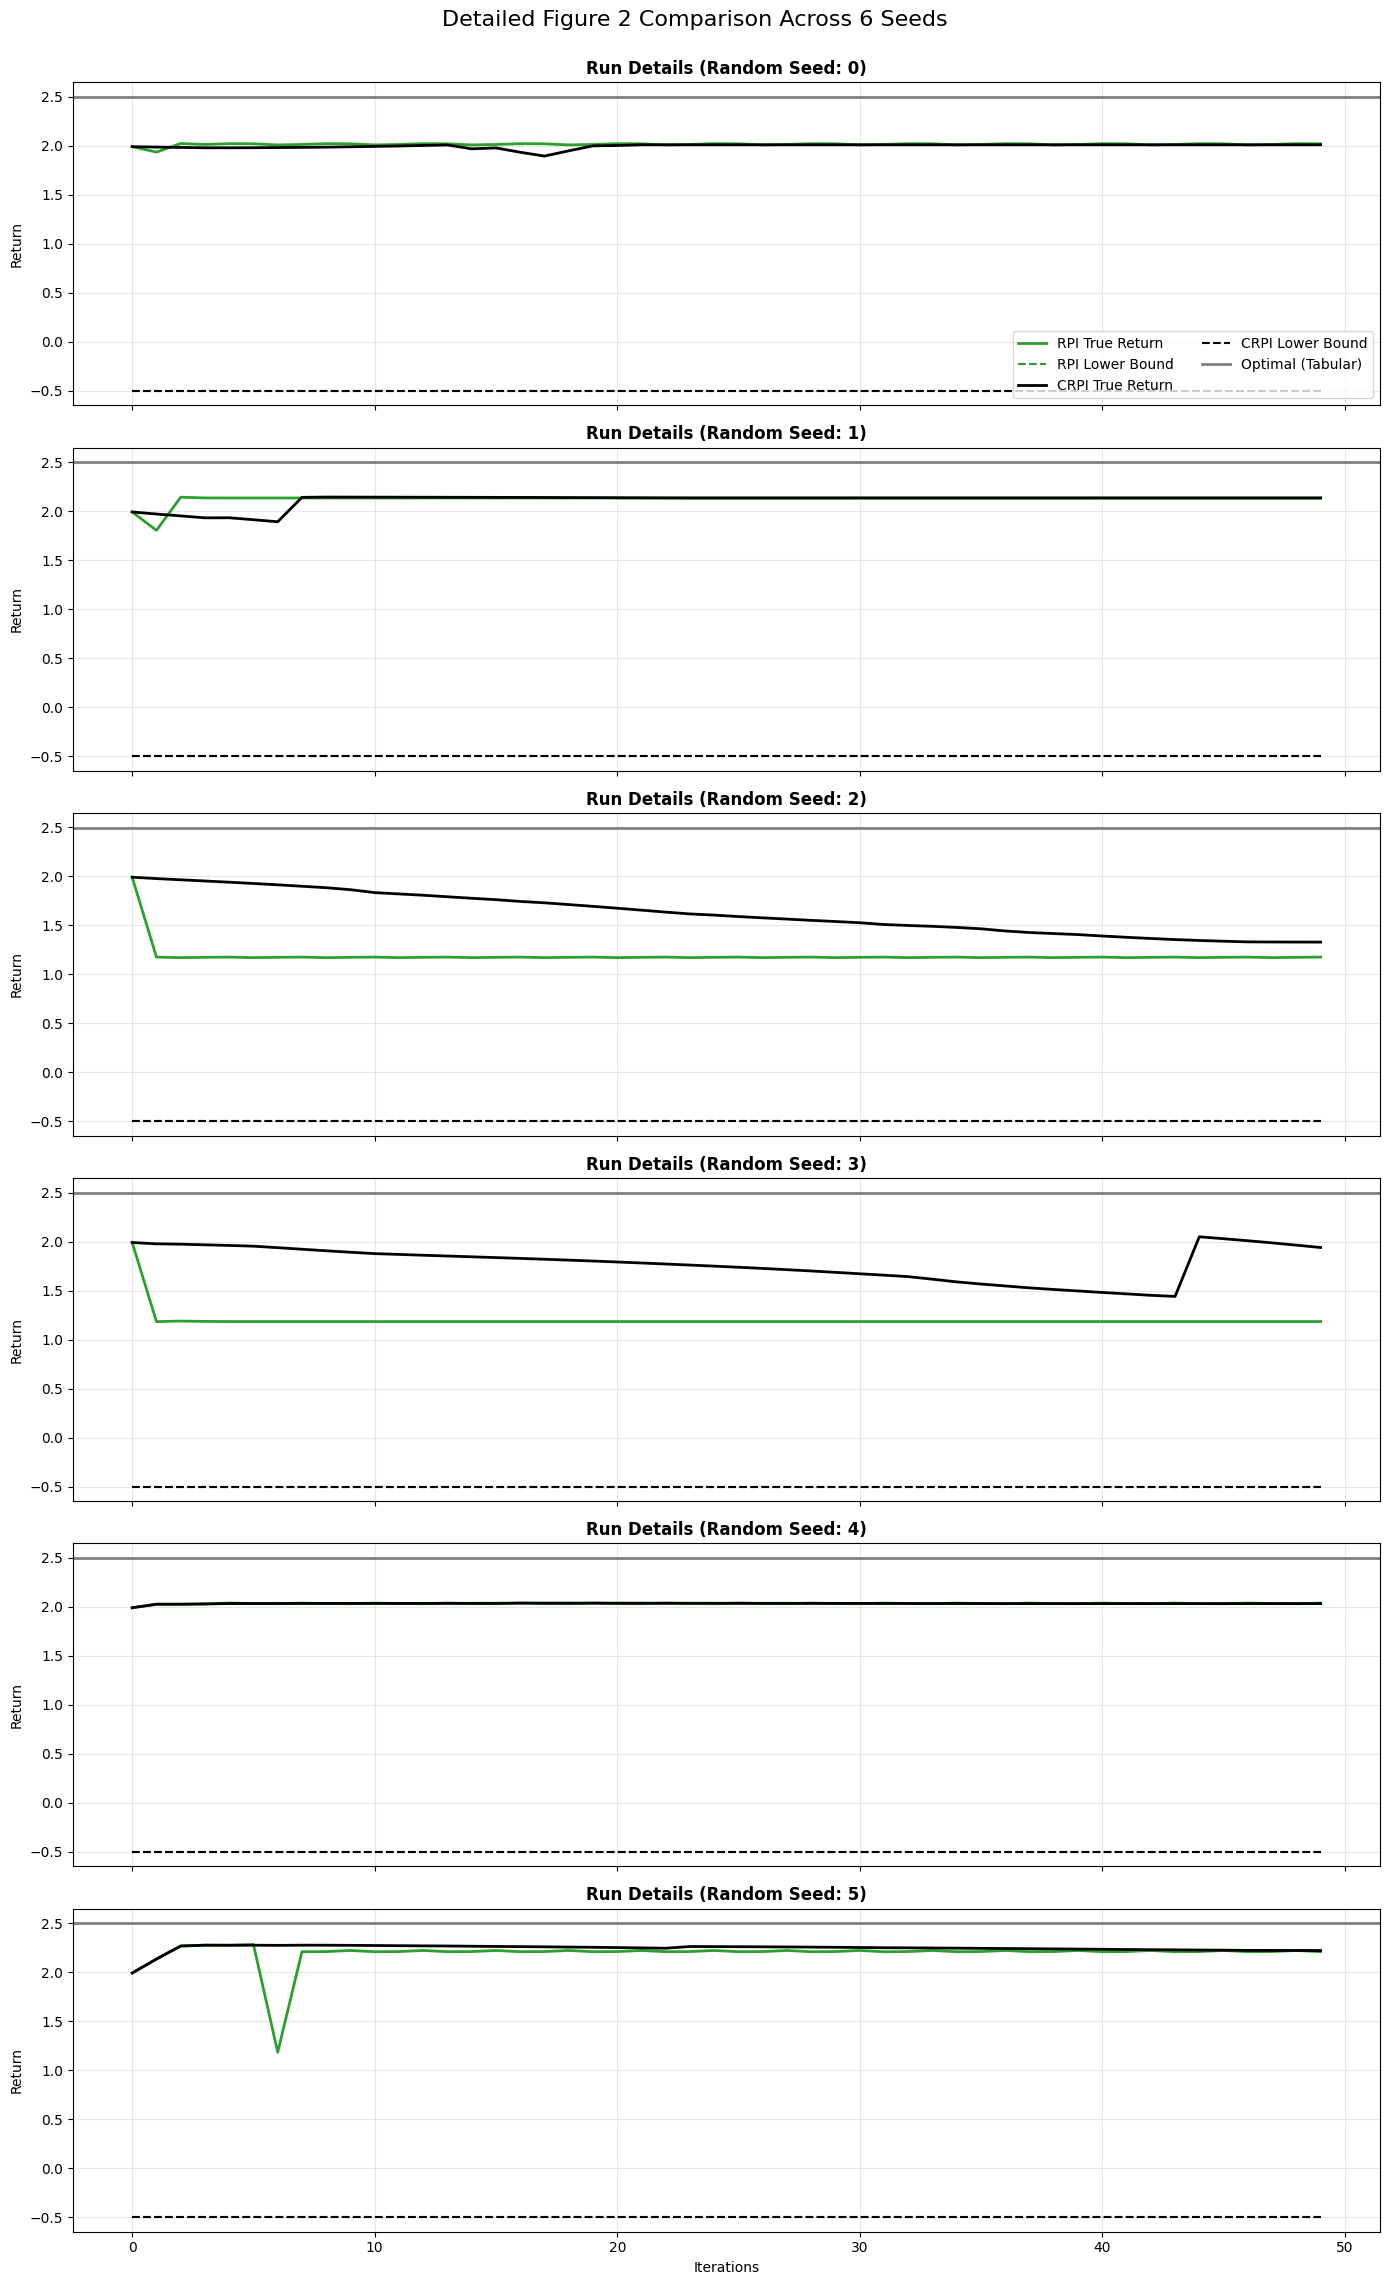

------------------------------
Average Terminal Performance across 6 Runs:
RPI: 1.794
CRPI: 1.945


In [ ]:
# --- CELL 3 ---
n_seeds = 6
# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a 5x1 grid of stacked subplots
fig, axes = plt.subplots(n_seeds, 1, figsize=(14, 4 * n_seeds), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across {n_seeds} Seeds", fontsize=16)

print(f"Running {n_seeds} detailed runs. This will take a moment...")

# Loop through each seed to train and plot immediately
for i in range(n_seeds):
    seed = i  # Keep seed consistent with index
    ax = axes[i]  # Get the current subplot

    # -- Fixed-Seed Feature Generation --
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0  # Bias column fix

    # -- 1. Train RPI --
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Random Seed: {seed})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Average Terminal Performance across {n_seeds} Runs:")
print(f"RPI: {np.mean(rpi_terminals):.3f}")
print(f"CRPI: {np.mean(crpi_terminals):.3f}")

Running 5 detailed runs with varying polynomial degrees. This will take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 comple

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:45: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.ECOS, max_iters=100)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:45: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.ECOS, max_iters=100)


CRPI Iteration 1/50 | alpha_k = 1.0000
CRPI Iteration 2/50 | alpha_k = 1.0000
CRPI Iteration 3/50 | alpha_k = 1.0000
CRPI Iteration 4/50 | alpha_k = 1.0000
CRPI Iteration 5/50 | alpha_k = 1.0000
CRPI Iteration 6/50 | alpha_k = 1.0000
CRPI Iteration 7/50 | alpha_k = 1.0000
CRPI Iteration 8/50 | alpha_k = 1.0000
CRPI Iteration 9/50 | alpha_k = 1.0000
CRPI Iteration 10/50 | alpha_k = 1.0000
CRPI Iteration 11/50 | alpha_k = 1.0000
CRPI Iteration 12/50 | alpha_k = 1.0000
CRPI Iteration 13/50 | alpha_k = 1.0000
CRPI Iteration 14/50 | alpha_k = 1.0000
CRPI Iteration 15/50 | alpha_k = 1.0000
CRPI Iteration 16/50 | alpha_k = 1.0000
CRPI Iteration 17/50 | alpha_k = 1.0000
CRPI Iteration 18/50 | alpha_k = 1.0000
CRPI Iteration 19/50 | alpha_k = 1.0000
CRPI Iteration 20/50 | alpha_k = 1.0000
CRPI Iteration 21/50 | alpha_k = 1.0000
CRPI Iteration 22/50 | alpha_k = 1.0000
CRPI Iteration 23/50 | alpha_k = 1.0000
CRPI Iteration 24/50 | alpha_k = 1.0000
CRPI Iteration 25/50 | alpha_k = 1.0000
CRPI Iter

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:45: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.ECOS, max_iters=100)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:45: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.ECOS, max_iters=100)


CRPI Iteration 1/50 | alpha_k = 0.0004
CRPI Iteration 2/50 | alpha_k = 0.0004
CRPI Iteration 3/50 | alpha_k = 0.0004
CRPI Iteration 4/50 | alpha_k = 0.0004
CRPI Iteration 5/50 | alpha_k = 0.0004
CRPI Iteration 6/50 | alpha_k = 0.0004
CRPI Iteration 7/50 | alpha_k = 0.0004
CRPI Iteration 8/50 | alpha_k = 0.0004
CRPI Iteration 9/50 | alpha_k = 0.0004
CRPI Iteration 10/50 | alpha_k = 0.0004
CRPI Iteration 11/50 | alpha_k = 0.0004
CRPI Iteration 12/50 | alpha_k = 0.0004
CRPI Iteration 13/50 | alpha_k = 0.0004
CRPI Iteration 14/50 | alpha_k = 0.0004
CRPI Iteration 15/50 | alpha_k = 0.0004
CRPI Iteration 16/50 | alpha_k = 0.0004
CRPI Iteration 17/50 | alpha_k = 0.0004
CRPI Iteration 18/50 | alpha_k = 0.0004
CRPI Iteration 19/50 | alpha_k = 0.0004
CRPI Iteration 20/50 | alpha_k = 0.0004
CRPI Iteration 21/50 | alpha_k = 0.0004
CRPI Iteration 22/50 | alpha_k = 0.0004
CRPI Iteration 23/50 | alpha_k = 0.0004
CRPI Iteration 24/50 | alpha_k = 0.0004
CRPI Iteration 25/50 | alpha_k = 0.0004
CRPI Iter

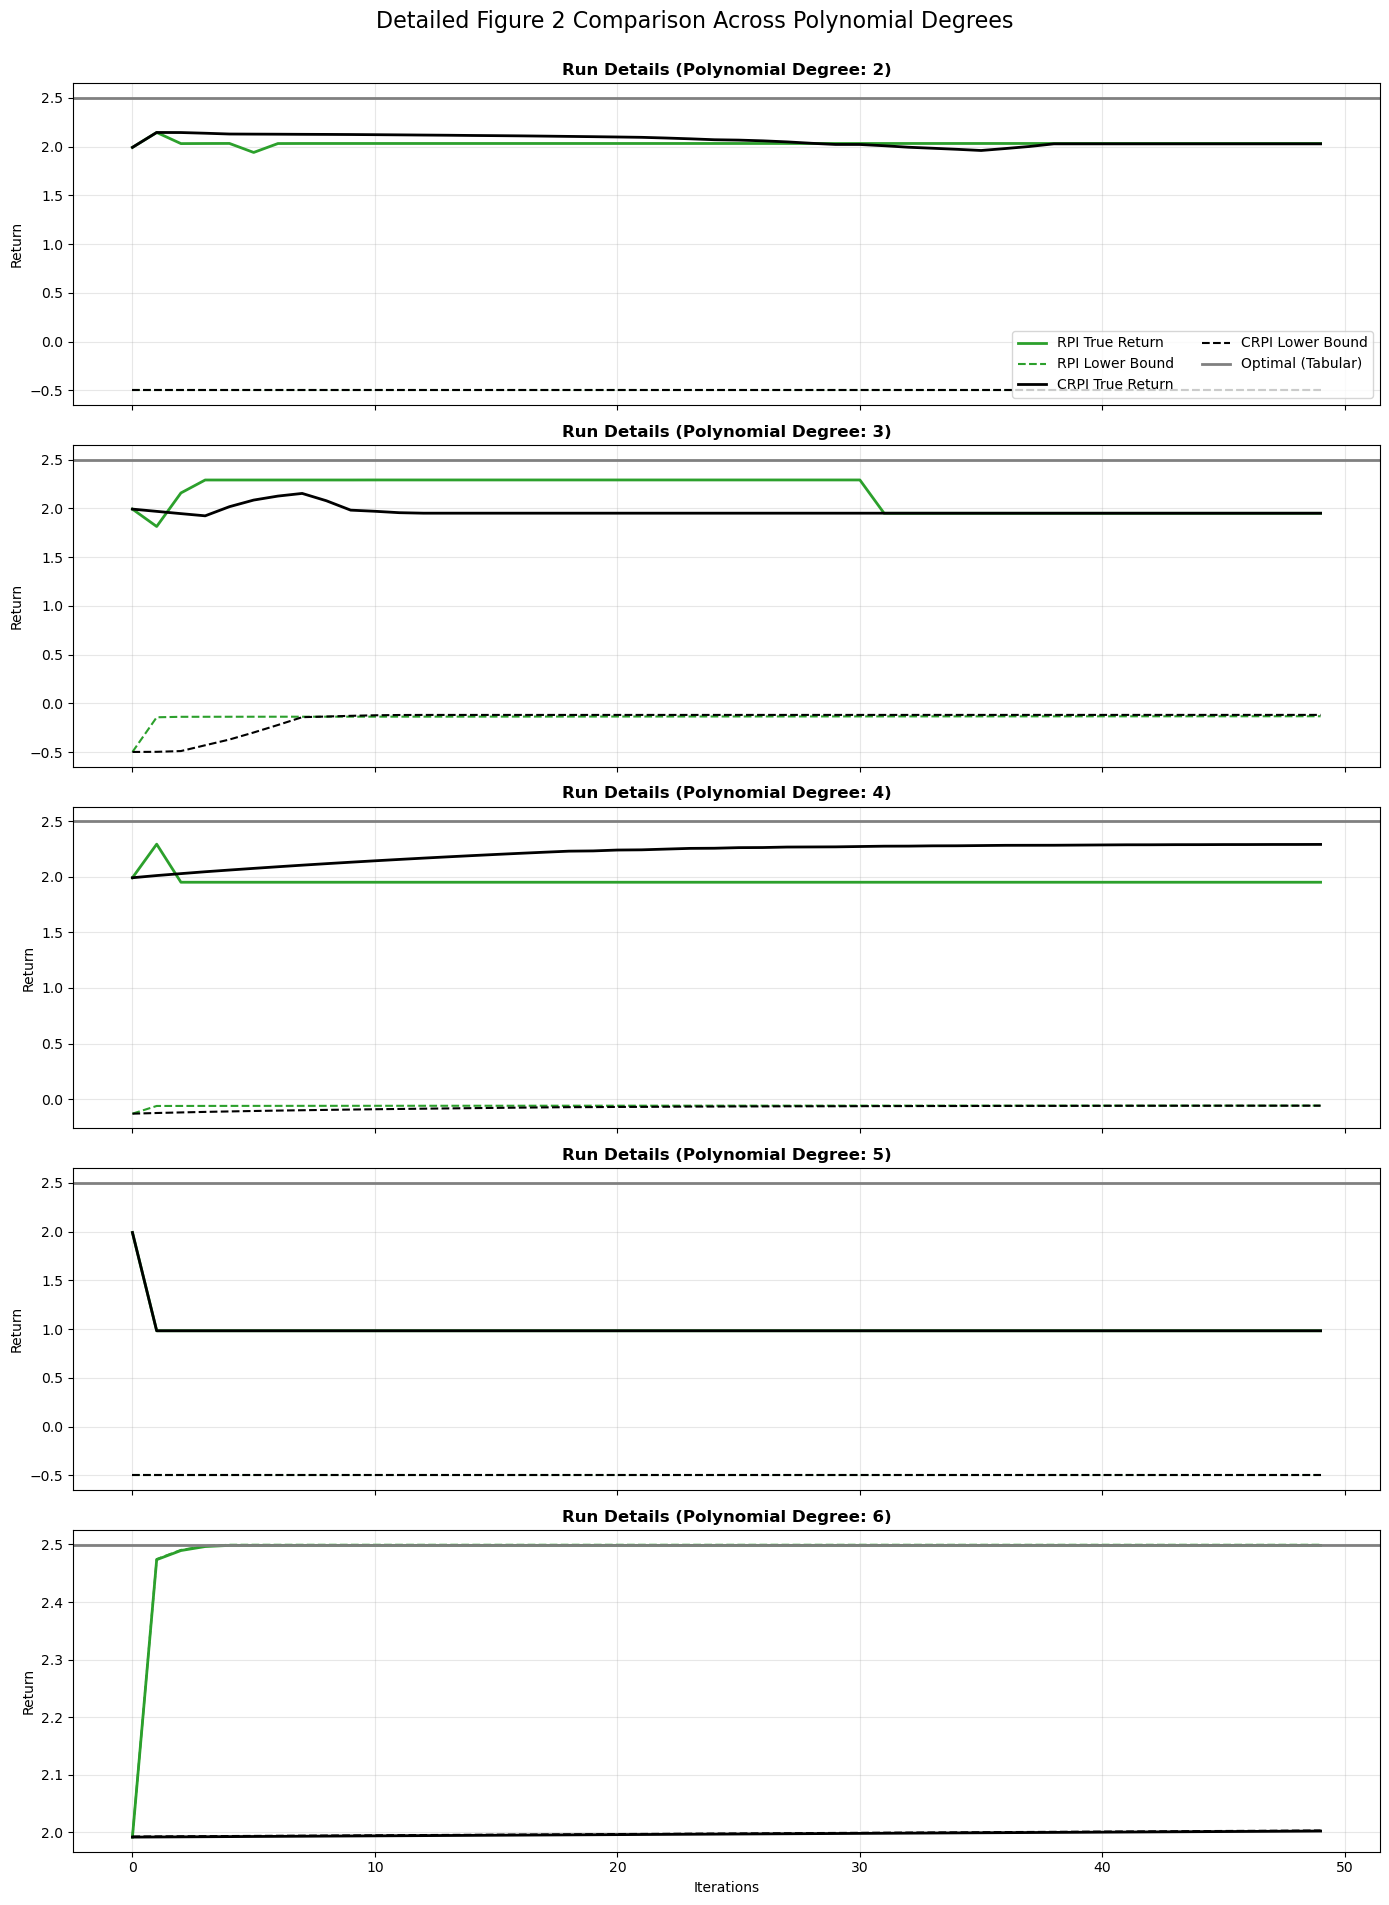

------------------------------
Terminal Performance across Polynomial Degrees:
Degree 2 -> RPI: 2.032 | CRPI: 2.028
Degree 3 -> RPI: 1.949 | CRPI: 1.949
Degree 4 -> RPI: 1.951 | CRPI: 2.291
Degree 5 -> RPI: 0.984 | CRPI: 0.984
Degree 6 -> RPI: 2.498 | CRPI: 2.002
------------------------------
Average Terminal Performance:
RPI Average: 1.883
CRPI Average: 1.851


In [4]:
# --- CELL 3 (Modified for Polynomial Degrees) ---
degrees = [2, 3, 4, 5, 6]
n_degrees = len(degrees)

# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a grid of stacked subplots based on the number of degrees
fig, axes = plt.subplots(n_degrees, 1, figsize=(14, 4 * n_degrees), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across Polynomial Degrees", fontsize=16)

print(f"Running {n_degrees} detailed runs with varying polynomial degrees. This will take a moment...")

# -- Fixed Base Feature Generation --
# Generate base features once so the comparison across degrees is fair
np.random.seed(42) 
# Note: Ensure 'SA' and 'd_features' (raw feature count) are defined in your notebook
Phi_raw = np.random.uniform(1, 5, size=(SA, d_features)) 

# Loop through each degree to train and plot immediately
for i, deg in enumerate(degrees):
    ax = axes[i]  # Get the current subplot

    # -- 1. Train RPI --
    # Use PolynomialFA with the current degree
    rpi_agent = RPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline (Assuming optimal_return is defined earlier)
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Polynomial Degree: {deg})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Terminal Performance across Polynomial Degrees:")
for idx, deg in enumerate(degrees):
    print(f"Degree {deg} -> RPI: {rpi_terminals[idx]:.3f} | CRPI: {crpi_terminals[idx]:.3f}")

print("-" * 30)
print(f"Average Terminal Performance:")
print(f"RPI Average: {np.mean(rpi_terminals):.3f}")
print(f"CRPI Average: {np.mean(crpi_terminals):.3f}")

Running 5 detailed runs with varying polynomial degrees. This will take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34/50 completed.
RPI Iteration 35/50 completed.
RPI Iteration 36/50 completed.
RPI Iteration 37/50 completed.
RPI Iteration 38/50 completed.
RPI Iterati

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 7/50 | alpha_k = 0.0396
CRPI Iteration 8/50 | alpha_k = 0.0421
CRPI Iteration 9/50 | alpha_k = 0.0450
CRPI Iteration 10/50 | alpha_k = 0.0485
CRPI Iteration 11/50 | alpha_k = 0.0505
CRPI Iteration 12/50 | alpha_k = 0.0300
CRPI Iteration 13/50 | alpha_k = 0.0296
CRPI Iteration 14/50 | alpha_k = 0.0296
CRPI Iteration 15/50 | alpha_k = 0.0315
CRPI Iteration 16/50 | alpha_k = 0.0346
CRPI Iteration 17/50 | alpha_k = 0.0356
CRPI Iteration 18/50 | alpha_k = 0.0346
CRPI Iteration 19/50 | alpha_k = 0.0330
CRPI Iteration 20/50 | alpha_k = 0.0309
CRPI Iteration 21/50 | alpha_k = 0.0285
CRPI Iteration 22/50 | alpha_k = 0.0264
CRPI Iteration 23/50 | alpha_k = 0.0244
CRPI Iteration 24/50 | alpha_k = 0.0218
CRPI Iteration 25/50 | alpha_k = 0.0200
CRPI Iteration 26/50 | alpha_k = 0.0185
CRPI Iteration 27/50 | alpha_k = 0.0149
CRPI Iteration 28/50 | alpha_k = 0.0167
CRPI Iteration 29/50 | alpha_k = 0.0184
CRPI Iteration 30/50 | alpha_k = 0.0169
CRPI Iteration 31/50 | alpha_k = 0.0154
CRP

...

CRPI Iteration 1/50 | alpha_k = 0.0001
CRPI Iteration 2/50 | alpha_k = 0.0002
CRPI Iteration 3/50 | alpha_k = 0.0010
CRPI Iteration 4/50 | alpha_k = 0.0004
CRPI Iteration 5/50 | alpha_k = 0.0026
CRPI Iteration 6/50 | alpha_k = 0.0026
CRPI Iteration 7/50 | alpha_k = 0.0026
CRPI Iteration 8/50 | alpha_k = 0.0026
CRPI Iteration 9/50 | alpha_k = 0.0026
CRPI Iteration 10/50 | alpha_k = 0.0026
CRPI Iteration 11/50 | alpha_k = 0.0026
CRPI Iteration 12/50 | alpha_k = 0.0026
CRPI Iteration 13/50 | alpha_k = 0.0026
CRPI Iteration 14/50 | alpha_k = 0.0026
CRPI Iteration 15/50 | alpha_k = 0.0026
CRPI Iteration 16/50 | alpha_k = 0.0026
CRPI Iteration 17/50 | alpha_k = 0.0026
CRPI Iteration 18/50 | alpha_k = 0.0026
CRPI Iteration 19/50 | alpha_k = 0.0026
CRPI Iteration 20/50 | alpha_k = 0.0026
CRPI Iteration 21/50 | alpha_k = 0.0026
CRPI Iteration 22/50 | alpha_k = 0.0026
CRPI Iteration 23/50 | alpha_k = 0.0026
CRPI Iteration 24/50 | alpha_k = 0.0026
CRPI Iteration 25/50 | alpha_k = 0.0027
CRPI Iter

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 1/50 | alpha_k = 0.0004
CRPI Iteration 2/50 | alpha_k = 0.0004
CRPI Iteration 3/50 | alpha_k = 0.0004
CRPI Iteration 4/50 | alpha_k = 0.0004
CRPI Iteration 5/50 | alpha_k = 0.0004
CRPI Iteration 6/50 | alpha_k = 0.0004
CRPI Iteration 7/50 | alpha_k = 0.0004
CRPI Iteration 8/50 | alpha_k = 0.0004
CRPI Iteration 9/50 | alpha_k = 0.0004
CRPI Iteration 10/50 | alpha_k = 0.0004
CRPI Iteration 11/50 | alpha_k = 0.0004
CRPI Iteration 12/50 | alpha_k = 0.0004
CRPI Iteration 13/50 | alpha_k = 0.0004
CRPI Iteration 14/50 | alpha_k = 0.0004
CRPI Iteration 15/50 | alpha_k = 0.0004
CRPI Iteration 16/50 | alpha_k = 0.0004
CRPI Iteration 17/50 | alpha_k = 0.0004
CRPI Iteration 18/50 | alpha_k = 0.0004
CRPI Iteration 19/50 | alpha_k = 0.0004
CRPI Iteration 20/50 | alpha_k = 0.0004
CRPI Iteration 21/50 | alpha_k = 0.0004
CRPI Iteration 22/50 | alpha_k = 0.0004
CRPI Iteration 23/50 | alpha_k = 0.0004
CRPI Iteration 24/50 | alpha_k = 0.0004
CRPI Iteration 25/50 | alpha_k = 0.0004
CRPI Iter

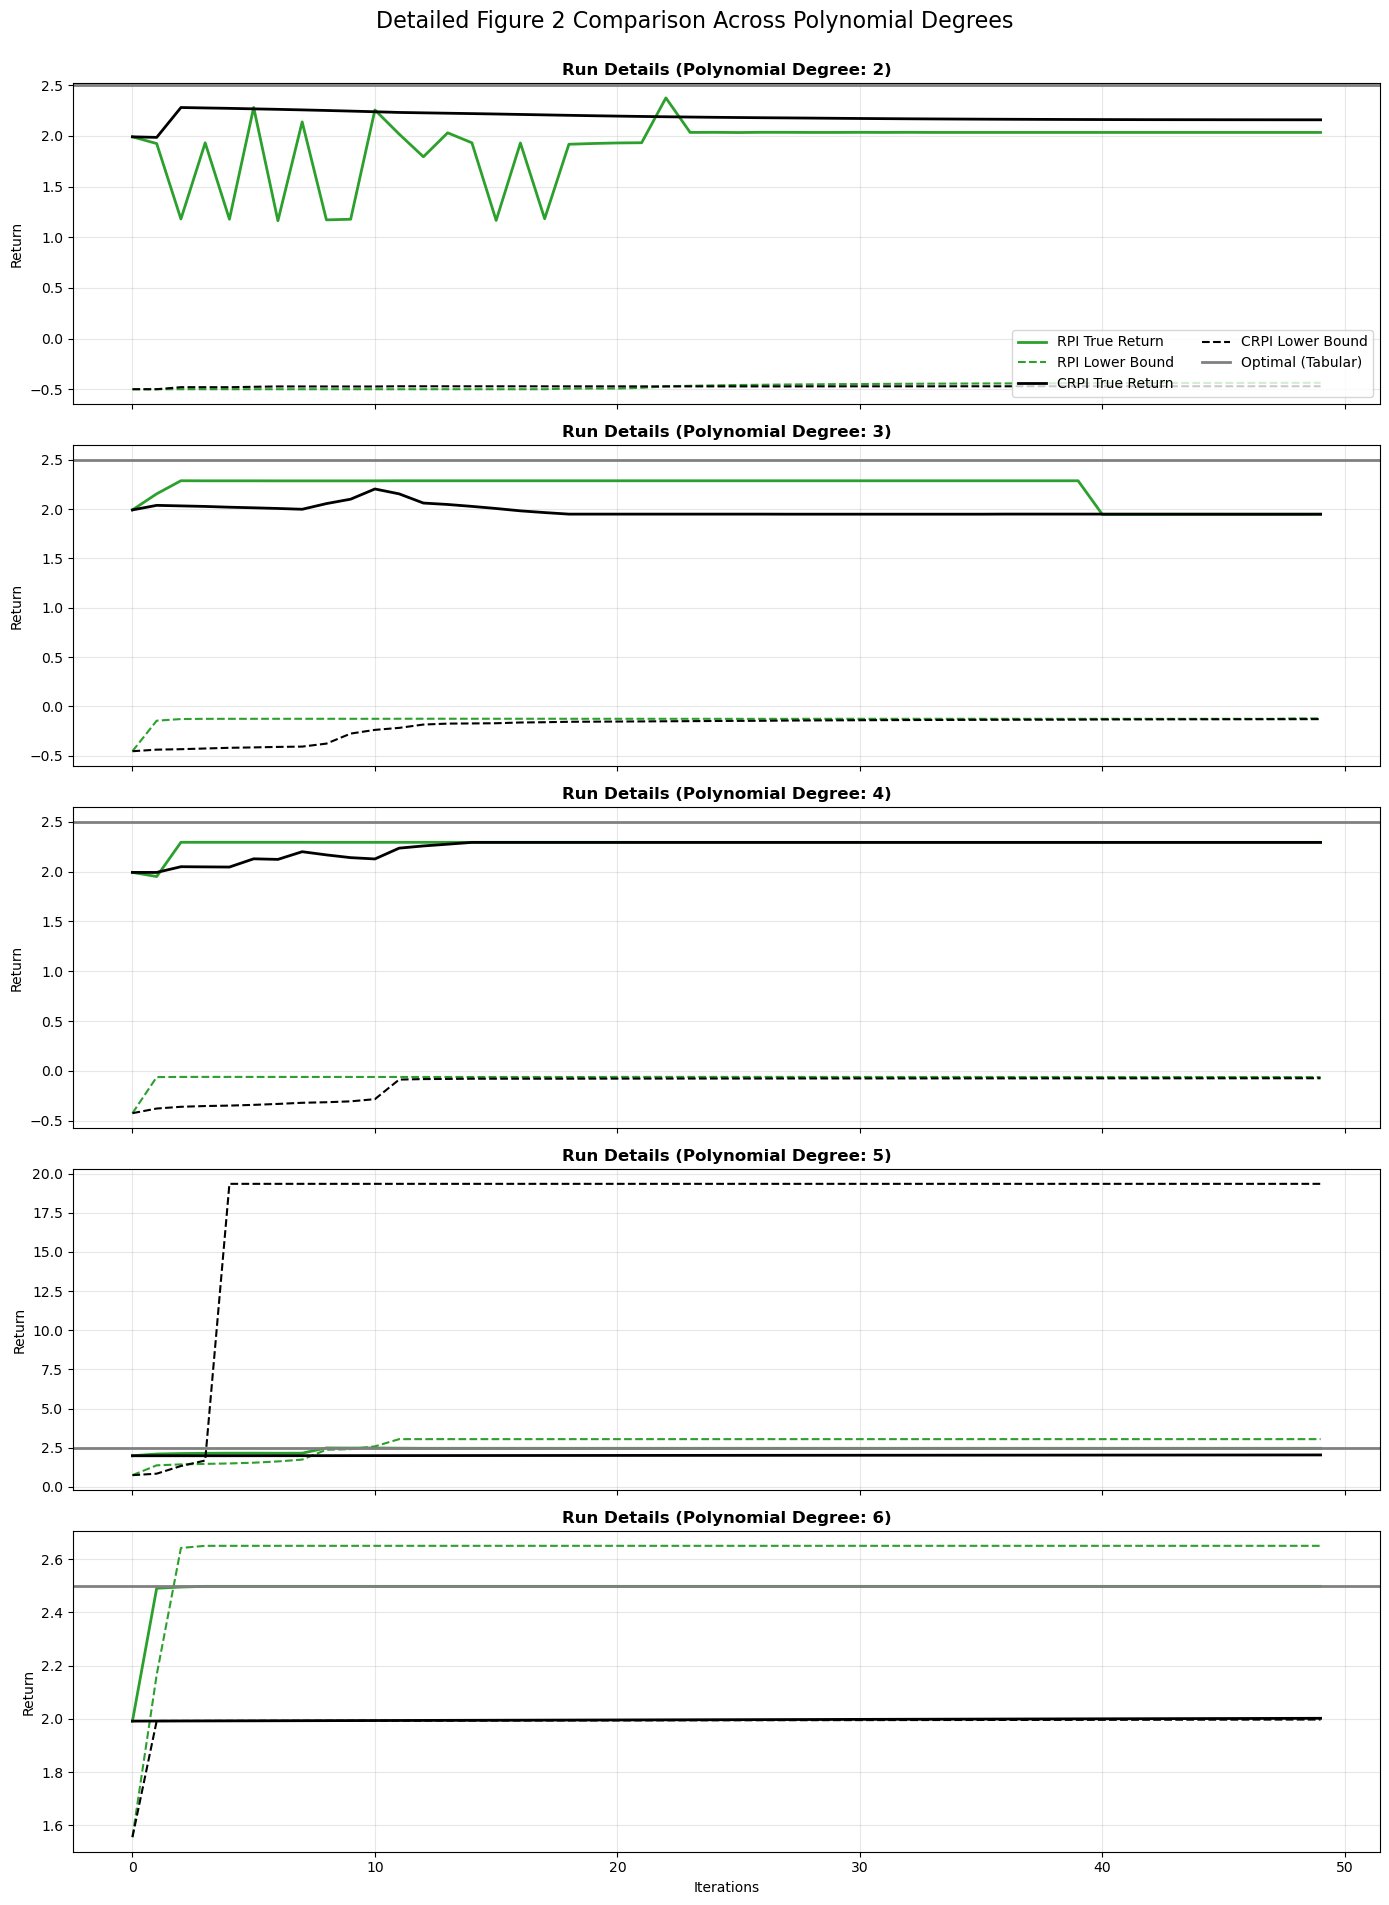

------------------------------
Terminal Performance across Polynomial Degrees:
Degree 2 -> RPI: 2.035 | CRPI: 2.159
Degree 3 -> RPI: 1.946 | CRPI: 1.949
Degree 4 -> RPI: 2.293 | CRPI: 2.293
Degree 5 -> RPI: 2.466 | CRPI: 2.042
Degree 6 -> RPI: 2.498 | CRPI: 2.002
------------------------------
Average Terminal Performance:
RPI Average: 2.248
CRPI Average: 2.089


In [4]:
# --- CELL 3 (Modified for Polynomial Degrees) ---
degrees = [2, 3, 4, 5, 6]
n_degrees = len(degrees)

# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a grid of stacked subplots based on the number of degrees
fig, axes = plt.subplots(n_degrees, 1, figsize=(14, 4 * n_degrees), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across Polynomial Degrees", fontsize=16)

print(f"Running {n_degrees} detailed runs with varying polynomial degrees. This will take a moment...")

# -- Fixed Base Feature Generation --
# Generate base features once so the comparison across degrees is fair
np.random.seed(42) 
# Note: Ensure 'SA' and 'd_features' (raw feature count) are defined in your notebook
Phi_raw = np.random.uniform(1, 5, size=(SA, d_features)) 

# Loop through each degree to train and plot immediately
for i, deg in enumerate(degrees):
    ax = axes[i]  # Get the current subplot

    # -- 1. Train RPI --
    # Use PolynomialFA with the current degree
    rpi_agent = RPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline (Assuming optimal_return is defined earlier)
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Polynomial Degree: {deg})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Terminal Performance across Polynomial Degrees:")
for idx, deg in enumerate(degrees):
    print(f"Degree {deg} -> RPI: {rpi_terminals[idx]:.3f} | CRPI: {crpi_terminals[idx]:.3f}")

print("-" * 30)
print(f"Average Terminal Performance:")
print(f"RPI Average: {np.mean(rpi_terminals):.3f}")
print(f"CRPI Average: {np.mean(crpi_terminals):.3f}")